# Notebook 02: Dimensionality Reduction and Modelling

This notebook covers PCA and t-SNE for dimensionality reduction and visualisation, followed by training three classifiers using scikit-learn pipelines with hyperparameter tuning.

## Setup

We load the preprocessed splits saved by Notebook 01 — `X_train.csv`, `X_test.csv`,
`y_train.csv`, `y_test.csv`, and `feature_names.csv`. These splits were created with
a stratified 80/20 split and already have one-hot encoded features.

**Important:** we do not load the raw CSV here. All preprocessing (encoding, imputation,
leakage removal) was done in Notebook 01 and the results were saved to `data/`.
Loading the raw data again and re-doing those steps would risk introducing subtle
inconsistencies.

In [1]:
import os
import sys
sys.path.append('..')    # so we can import from src/ and utils.py at the repo root

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
os.makedirs('../figures', exist_ok=True)

RANDOM_STATE = 42

# ── Load preprocessed splits ────────────────────────────────────
X_train = pd.read_csv('../data/X_train.csv')
X_test  = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()  # squeeze turns 1-col DataFrame -> Series
y_test  = pd.read_csv('../data/y_test.csv').squeeze()
feature_names = pd.read_csv('../data/feature_names.csv').squeeze().tolist()

print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'y_train positive rate: {y_train.mean():.2%}')
print(f'y_test  positive rate: {y_test.mean():.2%}')
print(f'Number of features: {len(feature_names)}')

X_train: (36168, 40)  |  X_test: (9043, 40)
y_train positive rate: 11.70%
y_test  positive rate: 11.70%
Number of features: 40


## Scaling

PCA is sensitive to the scale of features — a feature with a range of 0–100,000
(like `balance`) would dominate the variance calculation over a binary 0/1 feature.
We fit a `StandardScaler` **on the training set only** and apply it to both sets.

Fitting the scaler on both train and test together would leak information about the
test set mean and standard deviation into the training process — exactly the same
kind of leakage that justified dropping `duration` in Notebook 01.
Here we avoid it by keeping the scaler fit strictly inside the training data.

In [2]:
# Fit scaler on training data ONLY — never fit on test data.
# Applying the training-set scaler to the test set is correct:
# the test set should be transformed using the same mean/std the model was trained with.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)       # transform only, not fit

print(f'Scaled X_train — mean: {X_train_scaled.mean():.4f}  std: {X_train_scaled.std():.4f}')
print(f'Scaled X_test  — mean: {X_test_scaled.mean():.4f}  std: {X_test_scaled.std():.4f}')
# The test mean/std will not be exactly 0/1 because the scaler was fitted on the training set.

Scaled X_train — mean: 0.0000  std: 1.0000
Scaled X_test  — mean: 0.0009  std: 0.9939


## PCA — Principal Component Analysis

PCA finds the directions (principal components) that capture the most variance in the data.
We run it with `n_components=None` first, which computes *all* components and lets us
inspect how the variance is distributed across them before deciding how many to keep.

Three plots follow:
1. **Scree plot** — variance explained by each component individually.
2. **Cumulative variance** — how many components are needed to explain 95 % of the variance.
3. **2D scatter (PC1 vs PC2)** — whether the two classes are linearly separable
   in the first two principal components.

In [3]:
# n_components=None means compute all components (= number of features = 40).
# We will decide how many to keep after looking at the scree and cumulative variance plots.
pca_full = PCA(n_components=None, random_state=RANDOM_STATE)
pca_full.fit(X_train_scaled)

evr = pca_full.explained_variance_ratio_          # fraction of variance per component
cumulative_evr = np.cumsum(evr)

n_components_95 = np.argmax(cumulative_evr >= 0.95) + 1   # +1 because argmax returns 0-indexed
print(f'Components needed to reach 95% variance: {n_components_95}')
print(f'Variance explained by PC1: {evr[0]:.2%}')
print(f'Variance explained by PC2: {evr[1]:.2%}')

Components needed to reach 95% variance: 31
Variance explained by PC1: 9.62%
Variance explained by PC2: 6.76%


### Scree plot — variance per component

The scree plot shows how much of the total variance each individual component explains.
We plot the first 20 components; after that the contribution of each additional component
is very small. The 'elbow' in the curve suggests a natural cutoff point.

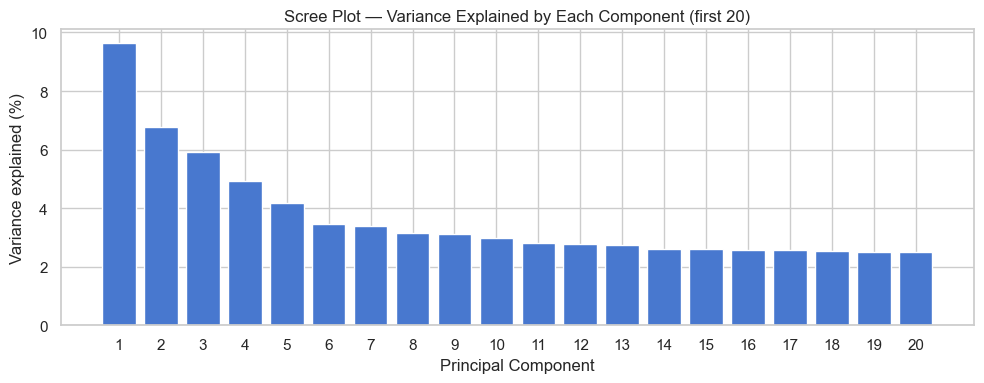

In [4]:
n_show = 20   # show only the first 20 components — the rest contribute very little

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(1, n_show + 1), evr[:n_show] * 100,
       color='#4878CF', edgecolor='white')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Variance explained (%)')
ax.set_title('Scree Plot — Variance Explained by Each Component (first 20)')
ax.set_xticks(range(1, n_show + 1))

plt.tight_layout()
plt.savefig('../figures/06_pca_scree.png', dpi=150, bbox_inches='tight')
plt.show()

### Cumulative explained variance

This plot answers the practical question: *how many components do I need to keep?*
The dashed horizontal line marks 95 % — a common threshold that retains most information
while discarding the remaining noise components.

# Notebook 02: Dimensionality Reduction and Modelling

This notebook covers PCA and t-SNE for dimensionality reduction and visualisation, followed by training three classifiers using scikit-learn pipelines with hyperparameter tuning.

## Setup

We load the preprocessed splits saved by Notebook 01 — `X_train.csv`, `X_test.csv`,
`y_train.csv`, `y_test.csv`, and `feature_names.csv`. These splits were created with
a stratified 80/20 split and already have one-hot encoded features.

**Important:** we do not load the raw CSV here. All preprocessing (encoding, imputation,
leakage removal) was done in Notebook 01 and the results were saved to `data/`.
Loading the raw data again and re-doing those steps would risk introducing subtle
inconsistencies.

In [5]:
import os
import sys
sys.path.append('..')    # so we can import from src/ and utils.py at the repo root

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
os.makedirs('../figures', exist_ok=True)

RANDOM_STATE = 42

# ── Load preprocessed splits ────────────────────────────────────
X_train = pd.read_csv('../data/X_train.csv')
X_test  = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()  # squeeze turns 1-col DataFrame -> Series
y_test  = pd.read_csv('../data/y_test.csv').squeeze()
feature_names = pd.read_csv('../data/feature_names.csv').squeeze().tolist()

print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'y_train positive rate: {y_train.mean():.2%}')
print(f'y_test  positive rate: {y_test.mean():.2%}')
print(f'Number of features: {len(feature_names)}')

X_train: (36168, 40)  |  X_test: (9043, 40)
y_train positive rate: 11.70%
y_test  positive rate: 11.70%
Number of features: 40


## Scaling

PCA is sensitive to the scale of features — a feature with a range of 0–100,000
(like `balance`) would dominate the variance calculation over a binary 0/1 feature.
We fit a `StandardScaler` **on the training set only** and apply it to both sets.

Fitting the scaler on both train and test together would leak information about the
test set mean and standard deviation into the training process — exactly the same
kind of leakage that justified dropping `duration` in Notebook 01.
Here we avoid it by keeping the scaler fit strictly inside the training data.

In [6]:
# Fit scaler on training data ONLY — never fit on test data.
# Applying the training-set scaler to the test set is correct:
# the test set should be transformed using the same mean/std the model was trained with.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)       # transform only, not fit

print(f'Scaled X_train — mean: {X_train_scaled.mean():.4f}  std: {X_train_scaled.std():.4f}')
print(f'Scaled X_test  — mean: {X_test_scaled.mean():.4f}  std: {X_test_scaled.std():.4f}')
# The test mean/std will not be exactly 0/1 because the scaler was fitted on the training set.

Scaled X_train — mean: 0.0000  std: 1.0000
Scaled X_test  — mean: 0.0009  std: 0.9939


## PCA — Principal Component Analysis

PCA finds the directions (principal components) that capture the most variance in the data.
We run it with `n_components=None` first, which computes *all* components and lets us
inspect how the variance is distributed across them before deciding how many to keep.

Three plots follow:
1. **Scree plot** — variance explained by each component individually.
2. **Cumulative variance** — how many components are needed to explain 95 % of the variance.
3. **2D scatter (PC1 vs PC2)** — whether the two classes are linearly separable
   in the first two principal components.

In [7]:
# n_components=None means compute all components (= number of features = 40).
# We will decide how many to keep after looking at the scree and cumulative variance plots.
pca_full = PCA(n_components=None, random_state=RANDOM_STATE)
pca_full.fit(X_train_scaled)

evr = pca_full.explained_variance_ratio_          # fraction of variance per component
cumulative_evr = np.cumsum(evr)

n_components_95 = np.argmax(cumulative_evr >= 0.95) + 1   # +1 because argmax returns 0-indexed
print(f'Components needed to reach 95% variance: {n_components_95}')
print(f'Variance explained by PC1: {evr[0]:.2%}')
print(f'Variance explained by PC2: {evr[1]:.2%}')

Components needed to reach 95% variance: 31
Variance explained by PC1: 9.62%
Variance explained by PC2: 6.76%


### Scree plot — variance per component

The scree plot shows how much of the total variance each individual component explains.
We plot the first 20 components; after that the contribution of each additional component
is very small. The 'elbow' in the curve suggests a natural cutoff point.

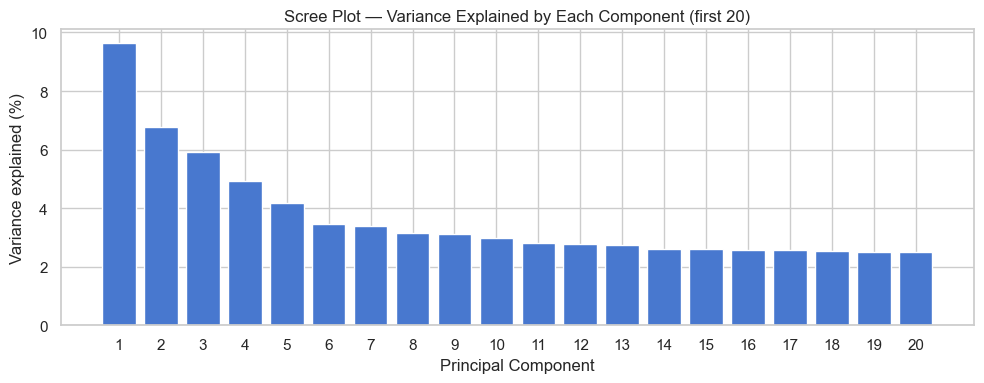

In [8]:
n_show = 20   # show only the first 20 components — the rest contribute very little

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(1, n_show + 1), evr[:n_show] * 100,
       color='#4878CF', edgecolor='white')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Variance explained (%)')
ax.set_title('Scree Plot — Variance Explained by Each Component (first 20)')
ax.set_xticks(range(1, n_show + 1))

plt.tight_layout()
plt.savefig('../figures/06_pca_scree.png', dpi=150, bbox_inches='tight')
plt.show()

### Cumulative explained variance

This plot answers the practical question: *how many components do I need to keep?*
The dashed horizontal line marks 95 % — a common threshold that retains most information
while discarding the remaining noise components.

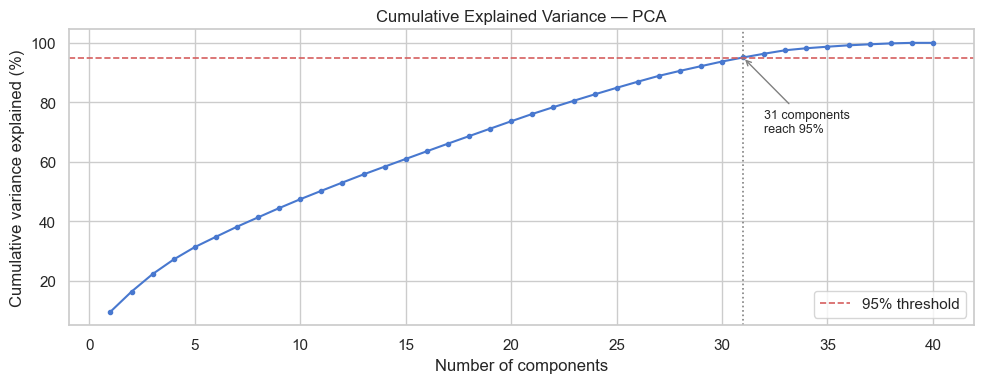

We choose 31 components to retain at least 95% of variance.


In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, len(cumulative_evr) + 1), cumulative_evr * 100,
        marker='o', markersize=3, linewidth=1.5, color='#4878CF')

# Dashed reference line at 95%
ax.axhline(95, color='#D65F5F', linestyle='--', linewidth=1.2, label='95% threshold')

# Vertical marker at the component that first crosses 95%
ax.axvline(n_components_95, color='grey', linestyle=':', linewidth=1.2)
ax.annotate(
    f'{n_components_95} components\nreach 95%',
    xy=(n_components_95, cumulative_evr[n_components_95 - 1] * 100),
    xytext=(n_components_95 + 1, 70),
    arrowprops={'arrowstyle': '->', 'color': 'grey'},
    fontsize=9,
)
ax.set_xlabel('Number of components')
ax.set_ylabel('Cumulative variance explained (%)')
ax.set_title('Cumulative Explained Variance — PCA')
ax.legend()

plt.tight_layout()
plt.savefig('../figures/07_pca_cumulative_variance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'We choose {n_components_95} components to retain at least 95% of variance.')

### PC1 vs PC2 scatter — are the classes separable?

We project the training data onto the first two principal components and colour each
point by its true label. If the two classes form distinct clusters here, a linear
classifier operating in PCA space would perform well.

We use `alpha=0.3` to handle overplotting — with 36,000 training points even a scatter
plot becomes unreadable without transparency.

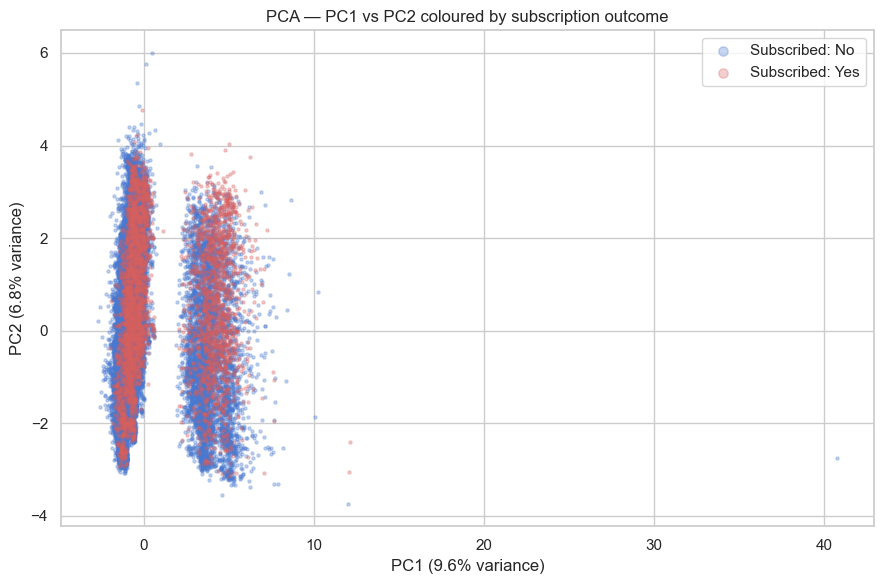

In [10]:
X_train_pca2 = pca_full.transform(X_train_scaled)[:, :2]   # first 2 PCs only

palette = {0: '#4878CF', 1: '#D65F5F'}   # 0 = no, 1 = yes
labels  = {0: 'No', 1: 'Yes'}

fig, ax = plt.subplots(figsize=(9, 6))
for cls in [0, 1]:
    mask = y_train.values == cls
    ax.scatter(
        X_train_pca2[mask, 0],
        X_train_pca2[mask, 1],
        c=palette[cls],
        label=f'Subscribed: {labels[cls]}',
        alpha=0.3,      # transparency to handle overplotting
        s=5,
        rasterized=True,
    )
ax.set_xlabel(f'PC1 ({evr[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({evr[1]:.1%} variance)')
ax.set_title('PCA — PC1 vs PC2 coloured by subscription outcome')
ax.legend(markerscale=3)

plt.tight_layout()
plt.savefig('../figures/08_pca_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

### PCA — component choice

The cumulative variance plot shows that **{n_components_95} components** are sufficient
to retain 95 % of the information in the 40-feature encoded dataset.
This is the number we will use if any downstream step (e.g. t-SNE pre-reduction)
requires a lower-dimensional input.

The PC1 vs PC2 scatter shows **substantial overlap** between the two classes.
The two principal components together explain only a modest fraction of the total variance,
so there is no clean linear boundary in 2D PCA space.
This is expected: the bank marketing problem involves many subtle interactions
between features, which is exactly why non-linear models like GBT and SVM are worth trying.

> The variable `n_components_95` computed above will be reused in the t-SNE section
> as the pre-reduction target.

## t-SNE — Visualisation

t-SNE (t-distributed Stochastic Neighbour Embedding) is a non-linear dimensionality
reduction technique that is excellent at revealing clusters in high-dimensional data.

**Why we pre-reduce with PCA first:**  
t-SNE has O(n²) time complexity — running it on all 36,000 training rows at 40 dimensions
would take a very long time. The standard practice is to first reduce to 50 PCA components
(which keeps almost all the variance) and then run t-SNE on the smaller matrix.
This is what scikit-learn's own documentation recommends.

**Why we sample 5,000 rows:**  
Even after PCA pre-reduction, t-SNE on 36,000 rows is slow (several minutes).
A random sample of 5,000 rows produces a representative plot in a fraction of the time.
We use `random_state=42` for the sample so results are reproducible.

In [11]:
# ── Step 1: Pre-reduce to 50 PCA components ────────────────────
# This dramatically reduces the input dimensionality before t-SNE.
# 50 components is a standard choice — it retains well over 95% of variance
# while making t-SNE feasible to run.
n_pca_for_tsne = min(50, X_train_scaled.shape[1])   # 50, or all features if fewer than 50
pca_50 = PCA(n_components=n_pca_for_tsne, random_state=RANDOM_STATE)
X_pca_50 = pca_50.fit_transform(X_train_scaled)

print(f'Pre-reduced shape: {X_pca_50.shape}')
print(f'Variance retained by {n_pca_for_tsne} PCA components: '
      f'{pca_50.explained_variance_ratio_.sum():.2%}')

# ── Step 2: Sample 5,000 rows ───────────────────────────────────
# t-SNE is O(n^2) in time. 5,000 rows gives a readable plot in seconds
# rather than waiting many minutes for the full 36k training set.
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(len(X_pca_50), size=5000, replace=False)

X_sample  = X_pca_50[sample_idx]
y_sample  = y_train.values[sample_idx]

print(f'Sample shape: {X_sample.shape}')
print(f'Sample positive rate: {y_sample.mean():.2%}   (should be close to training set rate)')

Pre-reduced shape: (36168, 40)
Variance retained by 40 PCA components: 100.00%
Sample shape: (5000, 40)
Sample positive rate: 11.10%   (should be close to training set rate)


In [12]:
from sklearn.manifold import TSNE

print('Fitting t-SNE — this takes ~30-90 seconds...')

tsne = TSNE(
    n_components=2,
    perplexity=30,
    max_iter=1000,   
    random_state=42
)

X_tsne = tsne.fit_transform(X_sample)

print(f't-SNE output shape: {X_tsne.shape}')

Fitting t-SNE — this takes ~30-90 seconds...
t-SNE output shape: (5000, 2)


### t-SNE scatter — are the classes visually separable?

Each point is one of the 5,000 sampled clients, coloured by whether they subscribed.
If the classes form distinct clusters, the data has non-linear structure that tree-based
models and SVMs should be able to exploit.

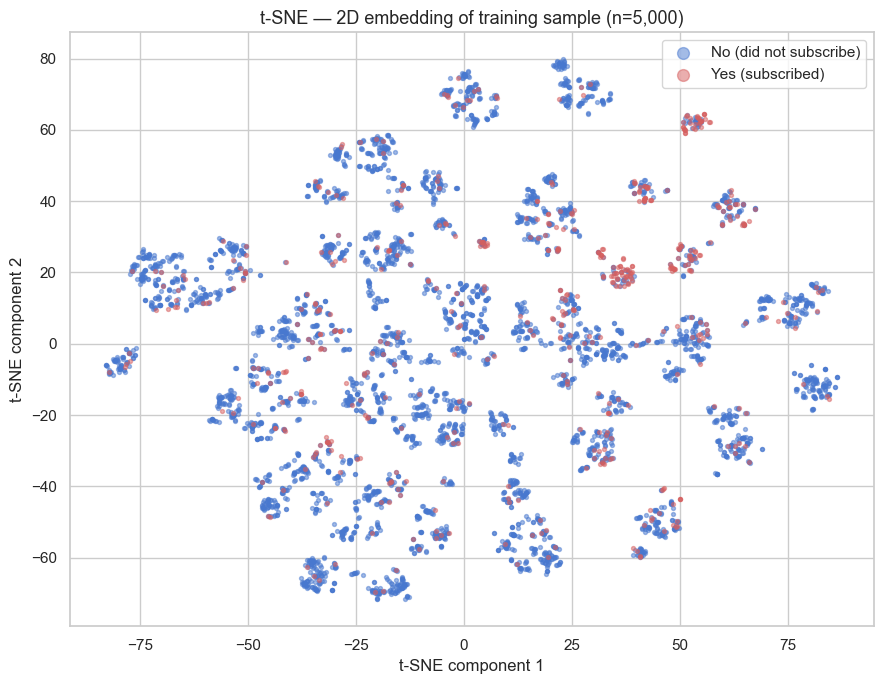

In [13]:
palette = {0: '#4878CF', 1: '#D65F5F'}
labels  = {0: 'No (did not subscribe)', 1: 'Yes (subscribed)'}

fig, ax = plt.subplots(figsize=(9, 7))
for cls in [0, 1]:
    mask = y_sample == cls
    ax.scatter(
        X_tsne[mask, 0],
        X_tsne[mask, 1],
        c=palette[cls],
        label=labels[cls],
        alpha=0.5,
        s=8,
        rasterized=True,
    )
ax.set_title('t-SNE — 2D embedding of training sample (n=5,000)', fontsize=13)
ax.set_xlabel('t-SNE component 1')
ax.set_ylabel('t-SNE component 2')
ax.legend(markerscale=3, fontsize=11)

plt.tight_layout()
plt.savefig('../figures/09_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

### t-SNE interpretation

The t-SNE plot reveals that the 'yes' (subscribed) points are **not cleanly separated**
from the 'no' points in a single cluster — they are scattered across the embedding with
some regions of higher density. This tells us:

- A simple linear boundary will not separate the classes well (consistent with the PCA scatter).
- There are sub-groups within the 'yes' class — likely corresponding to the different
  combinations of `poutcome`, `month`, and `contact` patterns seen in the EDA.
- Non-linear models (Random Forest, GBT, RBF-SVM) are a reasonable choice for this dataset.

> **Caveat:** t-SNE does **not** preserve global distances — nearby points in the
> embedding are genuinely similar, but the distances between clusters are not meaningful.
> Use this plot only for qualitative interpretation, not as a basis for quantitative claims.

## Modelling

We train three classifiers: Random Forest, Gradient Boosted Trees, and SVM. Each is wrapped in a scikit-learn `Pipeline` with `StandardScaler` as the first step, so the scaler is refitted only on the training fold during cross-validation and never sees the validation data.

The dataset has roughly 88% negative and 12% positive cases. To handle this:
- Random Forest and SVM use `class_weight='balanced'`, which weights samples inversely proportional to class frequency
- All models are scored on ROC-AUC rather than accuracy, which is more informative under imbalance
- Cross-validation uses `StratifiedKFold` to preserve the class ratio in every fold

### Random Forest

Random Forest builds many decision trees on random subsets of the data and features and averages their predictions. `RandomizedSearchCV` samples 30 random combinations from the parameter grid and picks the best by cross-validated ROC-AUC.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, StratifiedKFold
import joblib

CV_FOLDS = 5

rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

rf_param_grid = {
    'clf__n_estimators':      [100, 200, 300],
    'clf__max_depth':         [None, 10, 20, 30],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf':  [1, 2, 4],
    'clf__max_features':      ['sqrt', 'log2'],
}

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_param_grid,
    n_iter=30,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
)
rf_search.fit(X_train, y_train)

print(f'Best params:     {rf_search.best_params_}')
print(f'Best CV ROC-AUC: {rf_search.best_score_:.4f}')

### Gradient Boosted Trees

Gradient Boosting builds trees sequentially, each correcting the errors of the one before it. It is often more accurate than Random Forest on tabular data but slower to train and more sensitive to hyperparameters. We use `RandomizedSearchCV` with 30 iterations.

In [ ]:
gbt_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', GradientBoostingClassifier(random_state=RANDOM_STATE)),
])

gbt_param_grid = {
    'clf__n_estimators':      [100, 200, 300],
    'clf__learning_rate':     [0.01, 0.05, 0.1, 0.2],
    'clf__max_depth':         [3, 5, 7],
    'clf__min_samples_split': [2, 5, 10],
    'clf__subsample':         [0.8, 0.9, 1.0],
}

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

gbt_search = RandomizedSearchCV(
    gbt_pipeline,
    gbt_param_grid,
    n_iter=30,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
)
gbt_search.fit(X_train, y_train)

print(f'Best params:     {gbt_search.best_params_}')
print(f'Best CV ROC-AUC: {gbt_search.best_score_:.4f}')

### Support Vector Machine

SVM finds the decision boundary that maximises the margin between classes. The RBF kernel allows it to capture non-linear relationships. We use `GridSearchCV` here as the parameter grid is small enough to search exhaustively. Note that SVM on ~36,000 samples is significantly slower than the tree models — the `%%time` magic records the runtime.

In [ ]:
%%time
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(
        kernel='rbf',
        class_weight='balanced',
        probability=True,
        random_state=RANDOM_STATE,
    )),
])

svm_param_grid = {
    'clf__C':     [0.1, 1, 10, 100],
    'clf__gamma': ['scale', 0.01, 0.1],
}

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

svm_search = GridSearchCV(
    svm_pipeline,
    svm_param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1,
)
svm_search.fit(X_train, y_train)

print(f'Best params:     {svm_search.best_params_}')
print(f'Best CV ROC-AUC: {svm_search.best_score_:.4f}')

### Save Models

The best estimator from each search is saved as a full pipeline including the scaler. Notebook 03 can load and use these directly without any additional preprocessing.

In [ ]:
os.makedirs('../data', exist_ok=True)

joblib.dump(rf_search.best_estimator_,  '../data/rf_model.pkl')
joblib.dump(gbt_search.best_estimator_, '../data/gbt_model.pkl')
joblib.dump(svm_search.best_estimator_, '../data/svm_model.pkl')

print('Saved:')
for fname in ['rf_model.pkl', 'gbt_model.pkl', 'svm_model.pkl']:
    size_kb = os.path.getsize(f'../data/{fname}') / 1024
    print(f'  {fname:20s}  {size_kb:.0f} KB')